In [ ]:
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor
from sklearn.metrics import r2_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
import xgboost as xgb


In [ ]:
df = pd.read_csv("UserCarData.csv")
df = df.drop(["Sales_ID","torque"],axis=1)

In [ ]:
df.head()

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,sold
0,Maruti,2014,450000,145500,East,District of Columbia,Washington,Diesel,Individual,Manual,First_Owner,23.40,1248,74.00,5,Y
1,Skoda,2014,370000,120000,East,New York,New York City,Diesel,Individual,Manual,Second_Owner,21.14,1498,103.52,5,Y
2,Honda,2006,158000,140000,Central,Illinois,Chicago,Petrol,Individual,Manual,Third_Owner,17.70,1497,78.00,5,Y
3,Hyundai,2010,225000,127000,Central,Illinois,Chicago,Diesel,Individual,Manual,First_Owner,23.00,1396,90.00,5,Y
4,Maruti,2007,130000,120000,East,New York,New York City,Petrol,Individual,Manual,First_Owner,16.10,1298,88.20,5,Y


In [ ]:
df.info()

df = df.drop_duplicates(keep="first")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7906 entries, 0 to 7905
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               7906 non-null   object 
 1   year               7906 non-null   int64  
 2   selling_price      7906 non-null   int64  
 3   km_driven          7906 non-null   int64  
 4   Region             7906 non-null   object 
 5   State or Province  7906 non-null   object 
 6   City               7906 non-null   object 
 7   fuel               7906 non-null   object 
 8   seller_type        7906 non-null   object 
 9   transmission       7906 non-null   object 
 10  owner              7906 non-null   object 
 11  mileage            7906 non-null   float64
 12  engine             7906 non-null   int64  
 13  max_power          7906 non-null   float64
 14  seats              7906 non-null   int64  
 15  sold               7906 non-null   object 
dtypes: float64(2), int64(5),

# EDA



<Axes: xlabel='selling_price', ylabel='Count'>

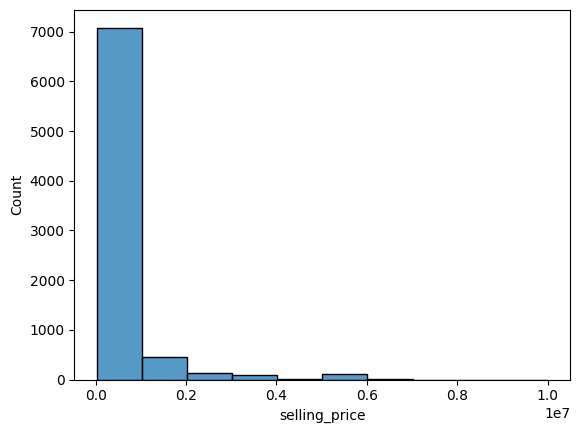

In [ ]:
sns.histplot(df["selling_price"],bins=10)



In [ ]:
# so our target is skewed  so later in our pipeline we will perfom log function to decrease its skewness
# but we can check the skewness of our target by applying the log transform on copy of our target

<Axes: xlabel='selling_price', ylabel='Count'>

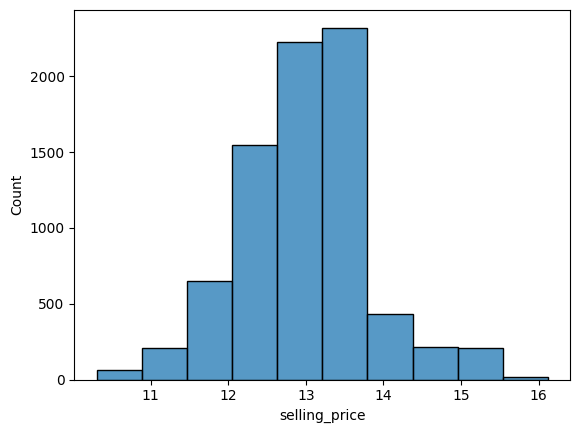

In [ ]:
eda_df = df.copy()
eda_df["selling_price"] = np.log1p(eda_df["selling_price"])

sns.histplot(eda_df["selling_price"],bins=10)

## numerical feature analysis

In [ ]:
num = df.select_dtypes(include=np.number).columns
num = num.drop("selling_price")

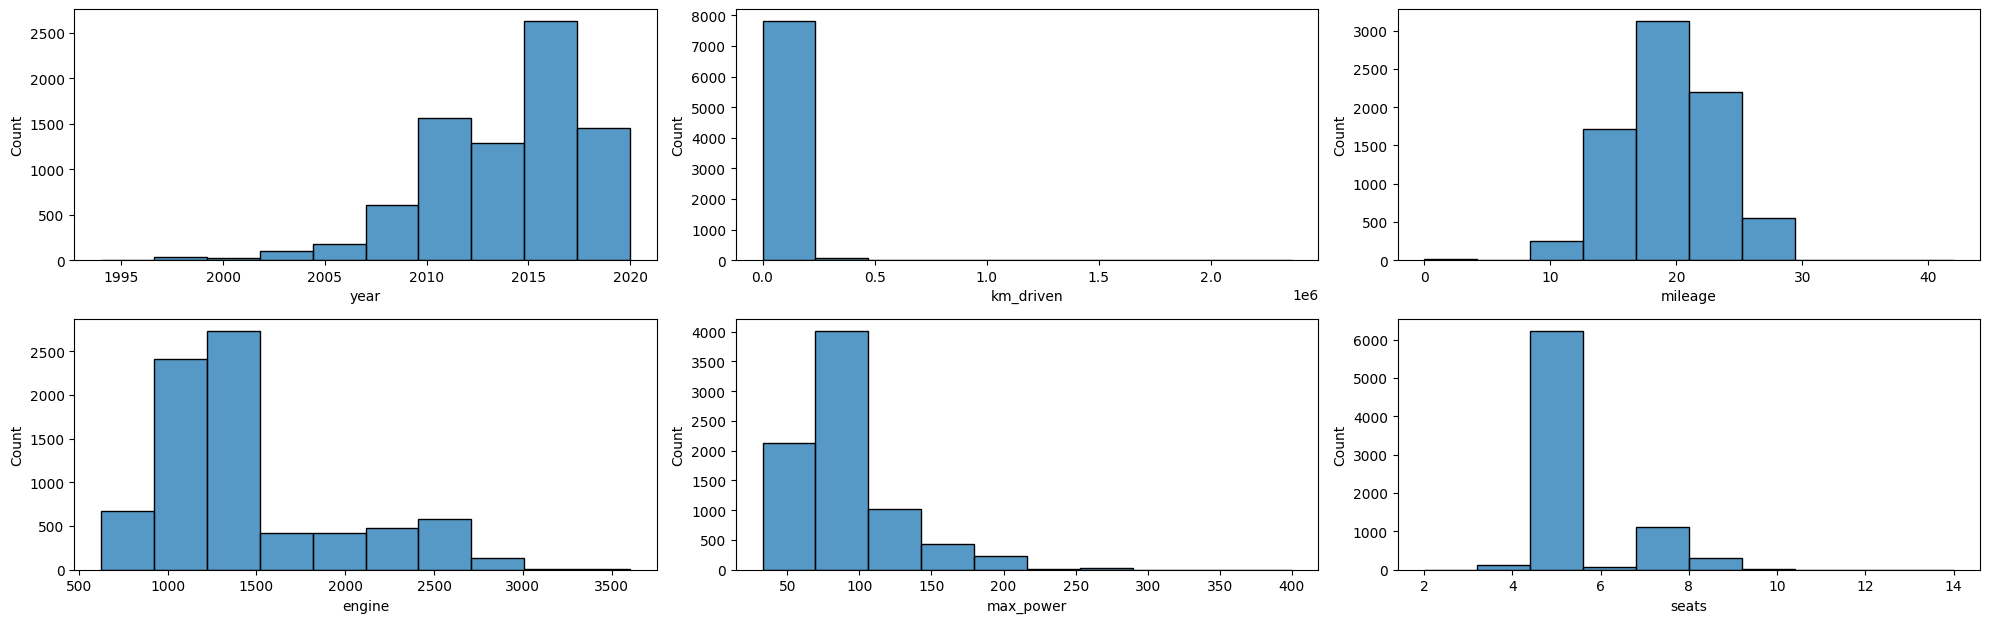

In [ ]:
plt.figure(figsize=(20,9))
for i,col in enumerate(num):
  plt.subplot(3,3,i+1)
  sns.histplot(df[col],bins=10)
  plt.tight_layout()




In [ ]:
''' so the km_driven is  right skewed so we want to apply log function later on our numerical pipeline   also little bit yearand max_power  it also skewed but we don't apply on it
because the skewness is not so big '''


" so the km_driven is  right skewed so we want to apply log function later on our numerical pipeline   also little bit yearand max_power  it also skewed but we don't apply on it\nbecause the skewness is not so big "

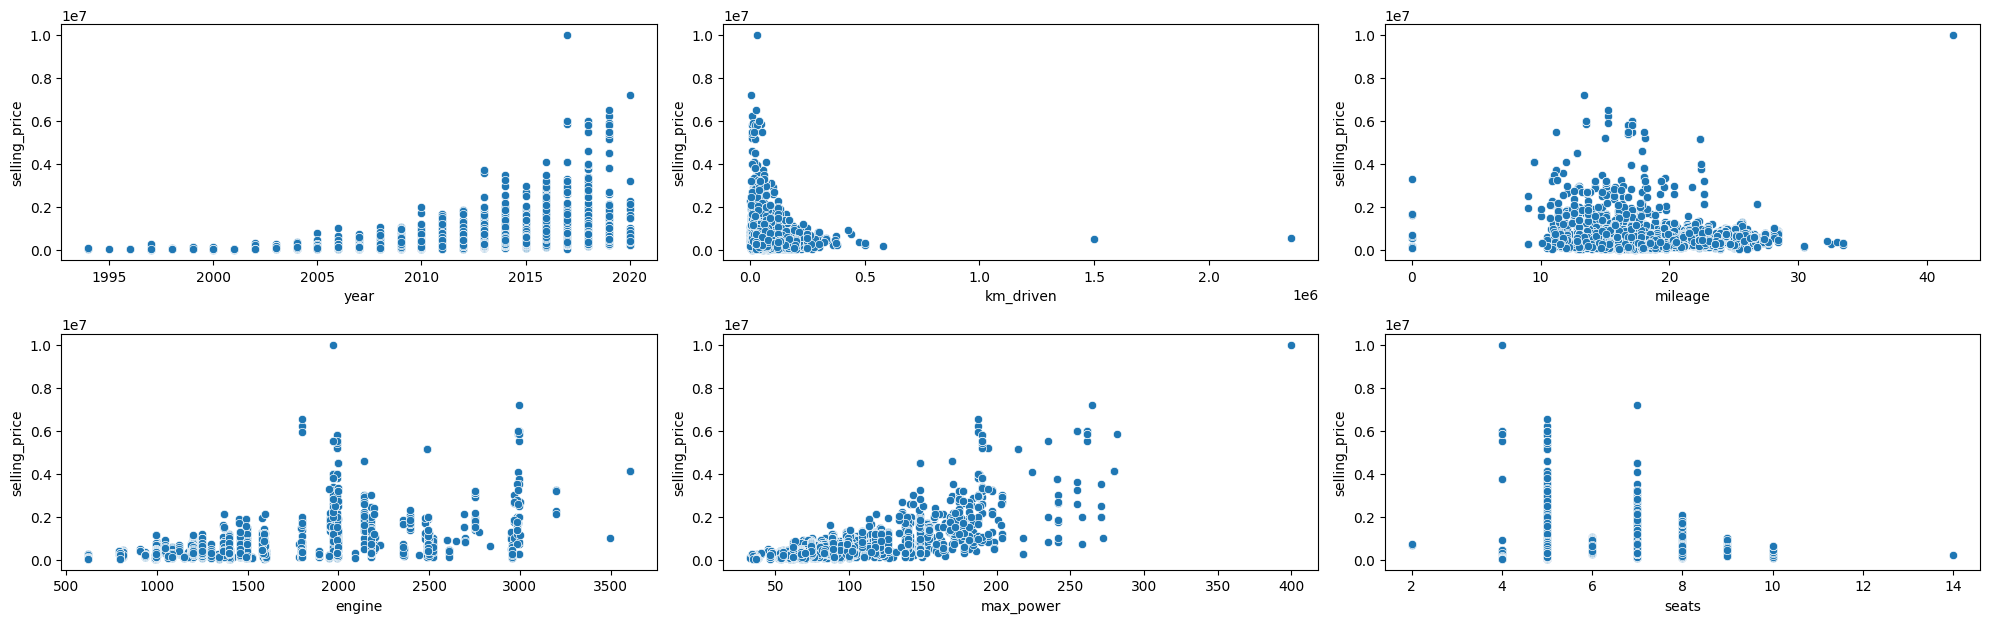

In [ ]:
plt.figure(figsize=(20,9))
for i,col in enumerate(num):
  plt.subplot(3,3,i+1)
  sns.scatterplot(x=df[col],y=df["selling_price"])
  plt.tight_layout()


# Using random_forest as base line project to select best numerical features

In [ ]:

model = RandomForestRegressor(random_state=42)


X_num = df[num]

y = df["selling_price"]


model.fit(X_num,y)

importance = pd.Series(model.feature_importances_,index=X_num.columns).sort_values(ascending=False)

importance


,0
max_power,0.735163
year,0.193516
km_driven,0.023771
mileage,0.022184
engine,0.021311
seats,0.004055


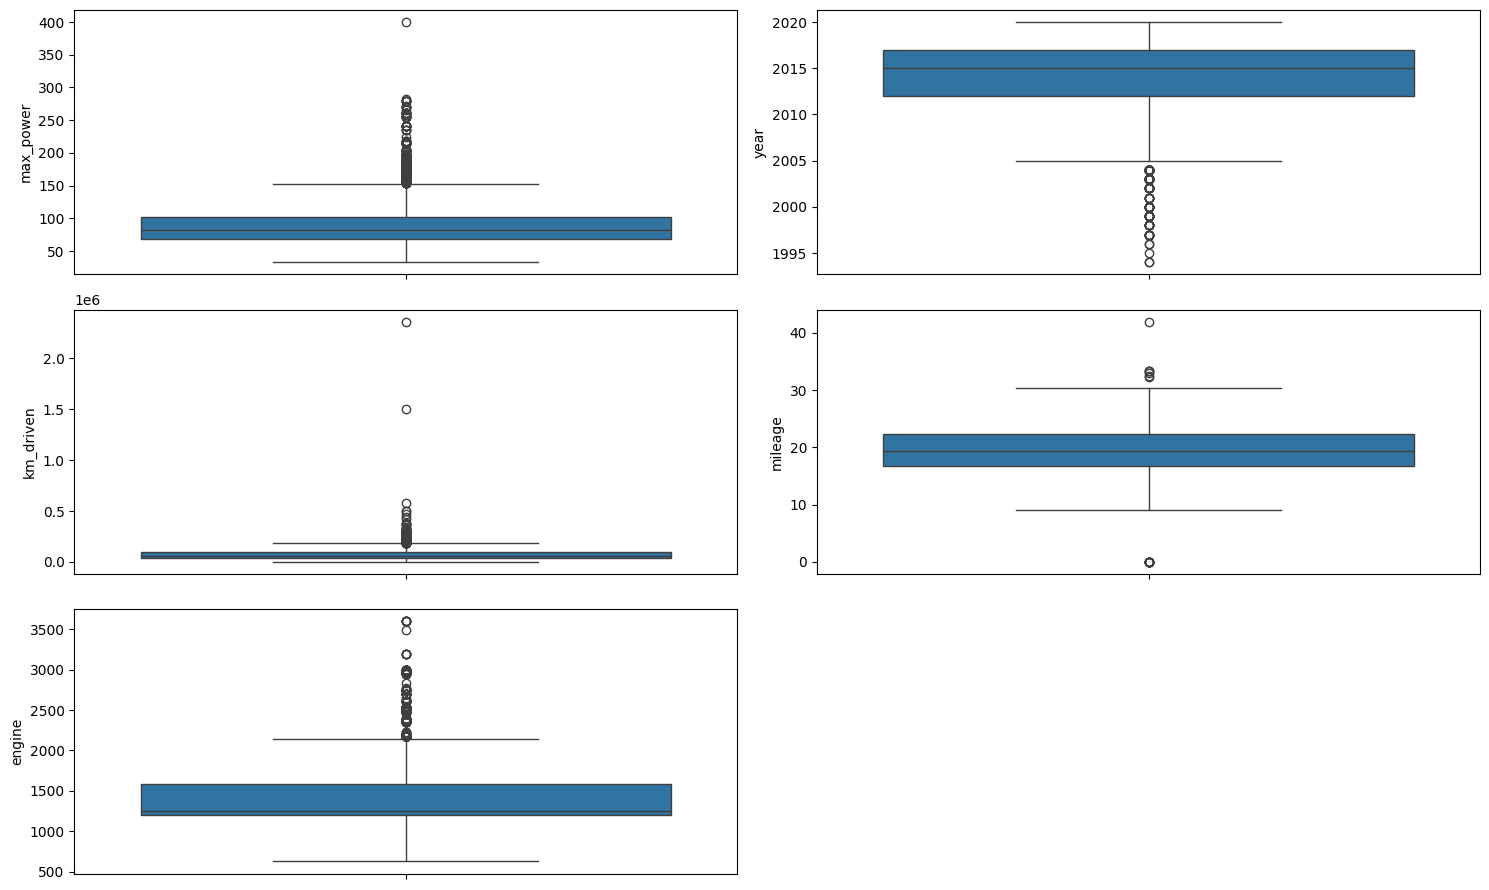

In [ ]:
selected_features = ["max_power","year","km_driven","mileage","engine"]
plt.figure(figsize=(15,9))
for i,feature in enumerate(selected_features):
  plt.subplot(3,2,i+1)
  sns.boxplot(y=feature,data=df)
  plt.tight_layout()


In [ ]:
df = df.drop("seats",axis=1)  #drop seat function because it is not giving that meaningfull insight in our dataset

# Correlation heatmap to check multicollinearity between features

<Axes: >

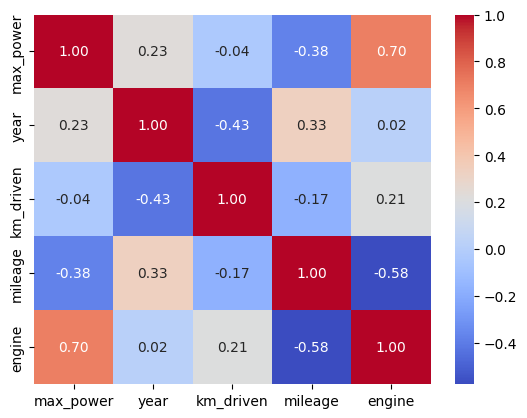

In [ ]:
corr = df[selected_features].corr()

sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")

# converting long categorical feature into short to perform EDA

In [ ]:
top_5_cities = eda_df["City"].value_counts().index[:5]

In [ ]:
eda_df["city_new"] = np.where(eda_df["City"].isin(top_5_cities),eda_df["City"],"other")

eda_df = eda_df.drop("City",axis=1)

In [ ]:
top_state = eda_df["State or Province"].value_counts().index[:5]

eda_df["state_new"]  = np.where(eda_df["State or Province"].isin(top_state),eda_df["State or Province"],"other")
eda_df = eda_df.drop("State or Province",axis=1)

In [ ]:
eda_df["state_new"].nunique()

car_name = eda_df["name"].value_counts().index[:5]
eda_df["car_name"] = np.where(eda_df["name"].isin(car_name),eda_df["name"],"other")

eda_df = eda_df.drop("name",axis=1)

In [ ]:
cat_col = eda_df.select_dtypes(include=["object"]).columns

In [ ]:
cat_col

Index(['Region', 'fuel', 'seller_type', 'transmission', 'owner', 'sold',
       'city_new', 'state_new', 'car_name'],
      dtype='object')

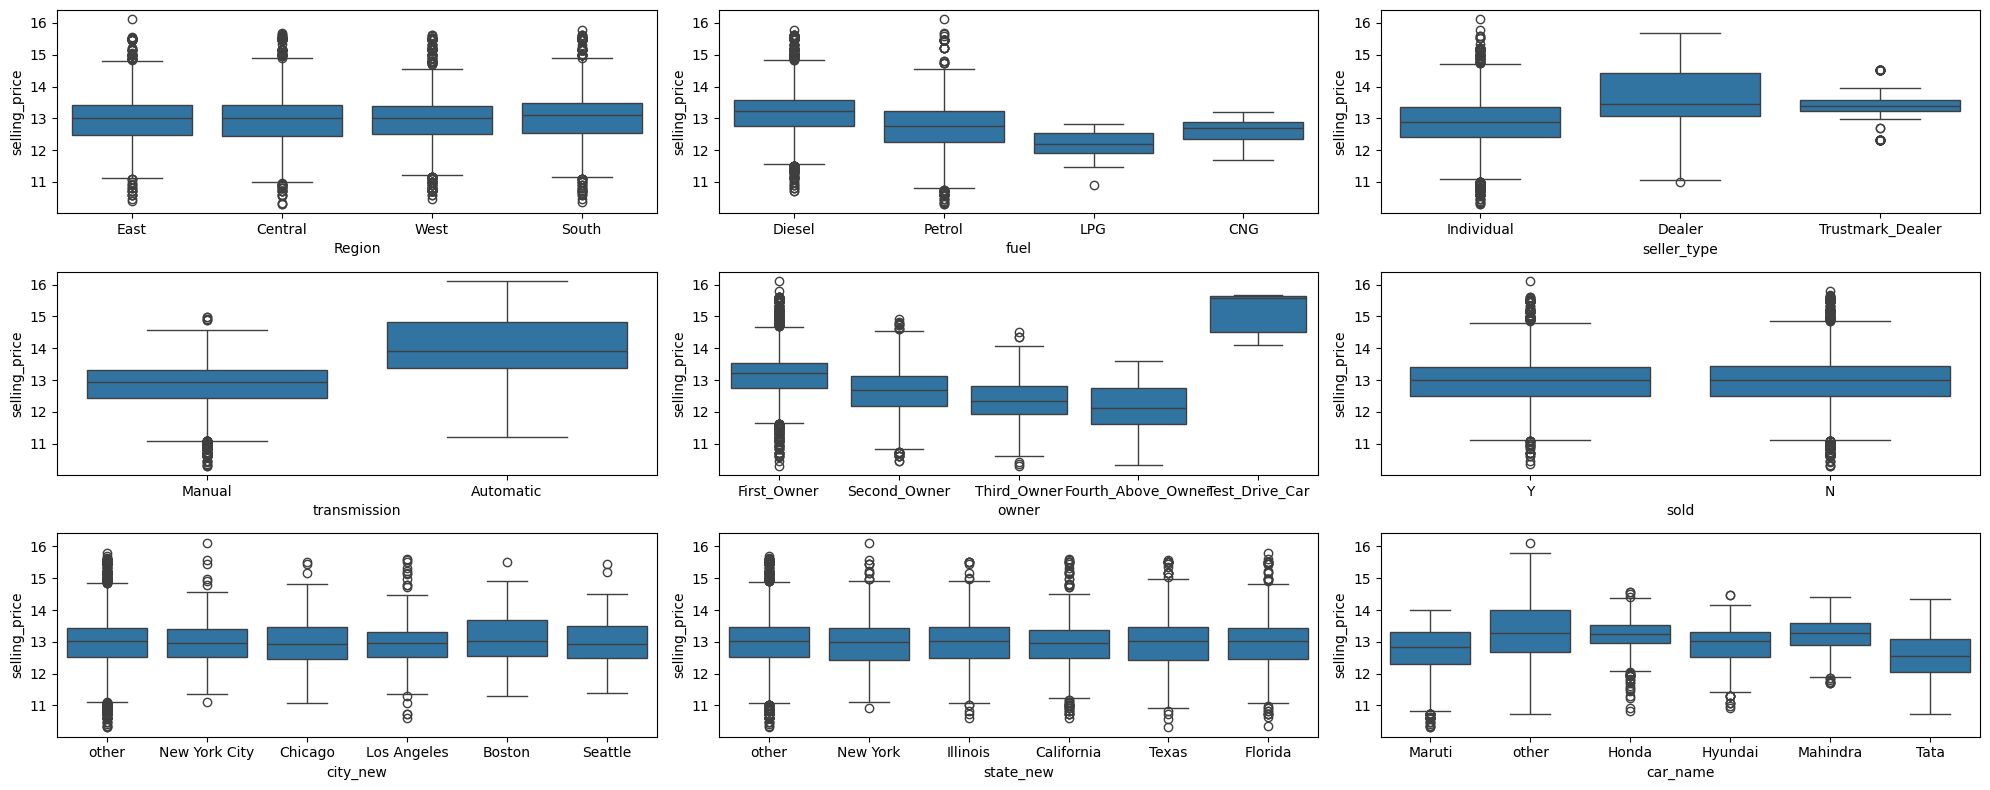

In [ ]:
plt.figure(figsize=(20,8))

for i, col in enumerate(cat_col):
  plt.subplot(3,3,i+1)
  sns.boxplot(x=col,y="selling_price",data=eda_df)
  plt.tight_layout()

In [ ]:
df = df.drop(["City","Region",'State or Province',"sold"],axis=1)

In [ ]:
current_year = datetime.datetime.now().year

df['age_of_car'] = current_year-df["year"]
df.drop("year",axis=1,inplace=True)

# Creating Machine learning models

In [ ]:
X = df.drop("selling_price",axis=1)
y= df["selling_price"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
numerical_col =  X.select_dtypes(include=np.number).columns.drop("km_driven")
category_col = X.select_dtypes(include="object").columns
log_col = ["km_driven"]

In [ ]:
class Iqrclipper(BaseEstimator,TransformerMixin):
   def __init__(self,factor=1.5):
    self.factor = factor
    self.lower_bound_ = None
    self.upper_bound_ = None

   def fit(self,X,y=None):
      X_df = pd.DataFrame(X)
      q1 = X_df.quantile(0.25)
      q3 = X_df.quantile(0.75)
      iqr = q3-q1

      self.lower_bound_ = q1 - self.factor * iqr
      self.upper_bound_ = q3 + self.factor * iqr
      return self

   def transform(self,X):
      X_df = pd.DataFrame(X).copy()
      return X_df.clip(lower=self.lower_bound_, upper=self.upper_bound_, axis=1)

In [ ]:

log_transformer = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="mean")),
        ("log",FunctionTransformer(np.log1p)),
        ("scaling",RobustScaler())
])
num_pipeline = Pipeline(
    steps=[
    ("imputer",SimpleImputer(strategy="mean")),
    ("outlier_clipping",Iqrclipper(factor=1.5)),
     ("scaling",RobustScaler())

])

col_pipeline = Pipeline(
    steps=[
     ("imputer",SimpleImputer(strategy="most_frequent")),
     ("one_hot",OneHotEncoder(sparse_output=False,max_categories=5,handle_unknown="infrequent_if_exist"))
])


preprocessor = ColumnTransformer(
  transformers=[
      ("numerical",num_pipeline,numerical_col),
      ("log_transform",log_transformer,log_col),
      ("categorical",col_pipeline,category_col)
  ]
)

In [ ]:


model_pipeline = Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("model",RandomForestRegressor(random_state=42))
    ]
)

def transform_target(regressor):     # this function is created to log transform target and then re-transform the log value to real value
 return TransformedTargetRegressor(
    regressor = regressor,
    func=np.log1p,
    inverse_func = np.expm1
)

rf_model = transform_target(model_pipeline)

In [ ]:
param_grid = {
    'regressor__model__n_estimators':[100,200,300],
    'regressor__model__max_depth': [2,4,5,10],
    'regressor__model__max_features': ["sqrt", "log2", None]

}

grid = GridSearchCV(
    estimator = rf_model,
    param_grid= param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1

)

grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                  inverse_func=<ufunc 'expm1'>,
                                                  regressor=Pipeline(steps=[('preprocess',
                                                                             ColumnTransformer(transformers=[('numerical',
                                                                                                              Pipeline(steps=[('imputer',
                                                                                                                               SimpleImputer()),
                                                                                                                              ('outlier_clipping',
                                                                                                                               Iqrclipper()),
                                                                                                                              ('scaling',
                                                                                                                               RobustScaler())]),
                                                                                                              Index(['mileage', 'engine', 'max_power', 'age_of_car'], dty...
                                                                                                                                             max_categories=5,
                                                                                                                                             sparse_output=False))]),
                                                                                                              Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object'))])),
                                                                            ('model',
                                                                             RandomForestRegressor(random_state=42))])),
             n_jobs=-1,
             param_grid={'regressor__model__max_depth': [2, 4, 5, 10],
                         'regressor__model__max_features': ['sqrt', 'log2',
                                                            None],
                         'regressor__model__n_estimators': [100, 200, 300]},
             scoring='r2')

In [ ]:
rf_best_estimator = grid.best_estimator_

In [ ]:
y_pred = rf_best_estimator.predict(X_test)
y_train_pred =  rf_best_estimator.predict(X_train)

In [ ]:
r2_score(y_train,y_train_pred)

0.9753675798530455

In [ ]:
svm_pipeline = Pipeline(steps=[
    ("preprocess",preprocessor),
    ("svm_model",SVR())
])

svm_final = transform_target(svm_pipeline)


param_grid = {
    "regressor__svm_model__C":[0.1,0.2],
    "regressor__svm_model__kernel": ["rbf","linear"]

}

svm_grid = GridSearchCV(
    estimator = svm_final,
    param_grid = param_grid,
    cv = 5,
    scoring ="r2",
    n_jobs = -1

)

svm_grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                  inverse_func=<ufunc 'expm1'>,
                                                  regressor=Pipeline(steps=[('preprocess',
                                                                             ColumnTransformer(transformers=[('numerical',
                                                                                                              Pipeline(steps=[('imputer',
                                                                                                                               SimpleImputer()),
                                                                                                                              ('outlier_clipping',
                                                                                                                               Iqrclipper()),
                                                                                                                              ('scaling',
                                                                                                                               RobustScaler())]),
                                                                                                              Index(['mileage', 'engine', 'max_power', 'age_of_car'], dty...
                                                                                                                               SimpleImputer(strategy='most_frequent')),
                                                                                                                              ('one_hot',
                                                                                                                               OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                                                                                             max_categories=5,
                                                                                                                                             sparse_output=False))]),
                                                                                                              Index(['name', 'fuel', 'seller_type', 'transmission', 'owner'], dtype='object'))])),
                                                                            ('svm_model',
                                                                             SVR())])),
             n_jobs=-1,
             param_grid={'regressor__svm_model__C': [0.1, 0.2],
                         'regressor__svm_model__kernel': ['rbf', 'linear']},
             scoring='r2')

In [ ]:
svm_best_estimator = svm_grid.best_estimator_


r2_score(y_test,svm_best_estimator.predict(X_test))

0.9067045741692248

In [ ]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("xgb",xgb.XGBRegressor(random_state=42))
         ])


xgb_final = transform_target(xgb_pipeline)

In [ ]:
param_grid ={
    "regressor__xgb__n_estimators":[100,200,300],
    "regressor__xgb__max_depth":[2,4,5,6,10],
    "regressor__xgb__learning_rate":[0.1,0.3,0.5]
}

Xgb_grid = GridSearchCV(
    estimator = xgb_final,
    param_grid = param_grid,
    cv=5,
    scoring = "r2",
    n_jobs=-1

)

Xgb_grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                  inverse_func=<ufunc 'expm1'>,
                                                  regressor=Pipeline(steps=[('preprocess',
                                                                             ColumnTransformer(transformers=[('numerical',
                                                                                                              Pipeline(steps=[('imputer',
                                                                                                                               SimpleImputer()),
                                                                                                                              ('outlier_clipping',
                                                                                                                               Iqrclipper()),
                                                                                                                              ('scaling',
                                                                                                                               RobustScaler())]),
                                                                                                              Index(['mileage', 'engine', 'max_power', 'age_of_car'], dty...
                                                                                          max_delta_step=None,
                                                                                          max_depth=None,
                                                                                          max_leaves=None,
                                                                                          min_child_weight=None,
                                                                                          missing=nan,
                                                                                          monotone_constraints=None,
                                                                                          multi_strategy=None,
                                                                                          n_estimators=None,
                                                                                          n_jobs=None,
                                                                                          num_parallel_tree=None, ...))])),
             n_jobs=-1,
             param_grid={'regressor__xgb__learning_rate': [0.1, 0.3, 0.5],
                         'regressor__xgb__max_depth': [2, 4, 5, 6, 10],
                         'regressor__xgb__n_estimators': [100, 200, 300]},
             scoring='r2')

In [ ]:
Xgb_final_estimator = Xgb_grid.best_estimator_

r2_score(y_test,Xgb_final_estimator.predict(X_test))

0.955363929271698

In [ ]:
raw_rf = rf_best_estimator.regressor_.named_steps['model']
raw_svm = svm_best_estimator.regressor_.named_steps['svm_model']
raw_xgb = Xgb_final_estimator.regressor_.named_steps['xgb']

estimators = [
    ("rf",raw_rf),
    ("svm",raw_svm),
    ("xgb",raw_xgb)
]

voting_pipeline = Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("voting",VotingRegressor(estimators=estimators))
    ]
)

voting_transformed = transform_target(voting_pipeline)


voting_transformed.fit(X_train,y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(transformers=[('numerical',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer()),
                                                                                                       ('outlier_clipping',
                                                                                                        Iqrclipper()),
                                                                                                       ('scaling',
                                                                                                        RobustScaler())]),
                                                                                       Index(['mileage', 'engine', 'max_power', 'age_of_car'], dtype='object')),
                                                                                      ('log_transfor...
                                                                                                feature_weights=None,
                                                                                                gamma=None,
                                                                                                grow_policy=None,
                                                                                                importance_type=None,
                                                                                                interaction_constraints=None,
                                                                                                learning_rate=0.3,
                                                                                                max_bin=None,
                                                                                                max_cat_threshold=None,
                                                                                                max_cat_to_onehot=None,
                                                                                                max_delta_step=None,
                                                                                                max_depth=5,
                                                                                                max_leaves=None,
                                                                                                min_child_weight=None,
                                                                                                missing=nan,
                                                                                                monotone_constraints=None,
                                                                                                multi_strategy=None,
                                                                                                n_estimators=300,
                                                                                                n_jobs=None,
                                                                                                num_parallel_tree=None, ...))]))]))

In [ ]:
r2_score(y_test,voting_transformed.predict(X_test))

0.9512010713674208

In [ ]:
stack_pipeline = Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("stacking",StackingRegressor(estimators=estimators,final_estimator=LinearRegression()))
    ]
)

stacking_transformed = transform_target(stack_pipeline)


stacking_transformed.fit(X_train,y_train)

In [ ]:
r2_score(y_test,stacking_transformed.predict(X_test))